**Table of contents**<a id='toc0_'></a>    
- [文件说明（File descriptions）](#toc1_)    
- [数据字段（Data fields）](#toc2_)    
- [导入库](#toc3_)    
- [EDA(数据探索性分析)](#toc4_)    
- [工具函数](#toc5_)    
- [数据预处理](#toc6_)    
- [特征工程](#toc7_)    
- [贝叶斯优化参数空间](#toc8_)    
- [合成数据生成（KNN插值版）](#toc9_)    
- [5 折交叉验证训练](#toc10_)    
- [模型融合](#toc11_)    
  - [加权融合（权重按 OOF F1 的幂次）](#toc11_1_)    
  - [Stacking（Logistic/RandomForest 选最佳）](#toc11_2_)    
- [提交文件](#toc12_)    
- [结果可视化](#toc13_)    

<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[文件说明（File descriptions）](#toc0_)
- train_set.csv - 训练集
- test_set.csv - 测试集
- sampled_submission.csv - 格式正确的提交文件示例


# <a id='toc2_'></a>[数据字段（Data fields）](#toc0_)
- unit_nr - 发动机编号（Unit Number）
- time_cycles - 运行周期数（Time Cycles，即当前的时间步）
- setting_1 - 操作设置 1（Operational Setting 1）
- setting_2 - 操作设置 2（Operational Setting 2）
- setting_3 - 操作设置 3（Operational Setting 3）
- Fan inlet temperature (◦R) - 风扇入口温度（Sensor T2）
- LPC outlet temperature (◦R) - 低压压气机出口温度（Sensor T24）
- HPC outlet temperature (◦R) - 高压压气机出口温度（Sensor T30）
- LPT outlet temperature (◦R) - 低压涡轮出口温度（Sensor T50）
- Fan inlet Pressure (psia) - 风扇入口压力（Sensor P2）
- bypass-duct pressure (psia) - 外涵道压力（Sensor P15）
- HPC outlet pressure (psia) - 高压压气机出口压力（Sensor P30）
- Physical fan speed (rpm) - 物理风扇转速（Sensor Nf）
- Physical core speed (rpm) - 物理核心转速（Sensor Nc）
- Engine pressure ratio (P50/P2) - 发动机压力比（Sensor epr）
- HPC outlet Static pressure (psia) - 高压压气机出口静压（Sensor Ps30）
- Ratio of fuel flow to Ps30 (pps/psia) - 燃油流量与 Ps30 比率（Sensor phi）
- Corrected fan speed (rpm) - 修正风扇转速（Sensor NRf）
- Corrected core speed (rpm) - 修正核心转速（Sensor NRc）
- Bypass Ratio - 涵道比（Sensor BPR）
- Burner fuel-air ratio - 燃烧室油气比（Sensor farB）
- Bleed Enthalpy - 引气焓（Sensor htBleed）
- Required fan speed - 要求风扇转速（Sensor Nf_dmd）
- Required fan conversion speed - 要求风扇转换转速（Sensor PCNfR_dmd）
- High-pressure turbines Cool air flow - 高压涡轮冷却气流（Sensor W31）
- Low-pressure turbines Cool air flow - 低压涡轮冷却气流（Sensor W32）
- RUL - 剩余使用寿命（Remaining Useful Life，目标预测值）

# <a id='toc3_'></a>[导入库](#toc0_)

In [1]:
# ==========================================
# 发动机故障预测（LightGBM + XGBoost + CatBoost）
# 1. 自动贝叶斯优化（LGB/XGB/CAT）
# 2. 数据合成
# 3. 五折 StratifiedKFold 训练
# 4. 加权融合 + Stacking
# 5. SHAP 解释性 + ROC/PR 可视化
# ==========================================
import warnings, os, random, gc, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 设置全局字体，支持中文显示
# ----------------------------
# 解决中文字体 & finXont 报错
# ----------------------------
import matplotlib as mpl

# 让 matplotlib 走 “sans-serif 字体族”
mpl.rcParams["font.family"] = "sans-serif"

# 让中文字体排在最前（有哪个用哪个）
mpl.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC",      # 你装了 fonts-noto-cjk 后通常就有
    "WenQuanYi Zen Hei",     # fonts-wqy-zenhei
    "WenQuanYi Micro Hei",   # fonts-wqy-microhei
    "SimHei",                # 万一你后来自己装了 SimHei
    "Microsoft YaHei",
    "Arial Unicode MS",
    "DejaVu Sans",           # 最后兜底（不保证中文）
]

# 负号正常显示
mpl.rcParams["axes.unicode_minus"] = False


from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
    RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import shap
shap.initjs()

In [2]:
TRAIN_PATH = "train_set.csv"
TEST_PATH = "test_set.csv"
SAMPLE_SUB_PATH = "sampled_submission.csv"
SUBMISSION_OUT = "submission.csv"
LABEL = 'RUL'  # 标签名
LABEL_DESC = 'rul'  # 标签描述（在可视化中描述比较抽象的标签名，比如 Target 等）

In [3]:
# ------------------------------------------------------------------
# Paper figures export (WHITELIST)
# 仅将白名单中的论文图表额外保存到 paper_figs/，其余一律不保存到该目录
# ------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
PAPER_FIG_DIR = "paper_figs"  # 论文图表保存目录
EXP_FIG_DIR = "exp_figs"  # 普通实验图表保存目录
os.makedirs(PAPER_FIG_DIR, exist_ok=True)
os.makedirs(EXP_FIG_DIR, exist_ok=True)

# 白名单：仅保留论文中除 Fig.1 之外提到的图表/表格
PAPER_WHITELIST = {
    # Figures (paper)
    "fig2_corr_heatmap.png",
    "fig3_shap_bar.png",
    "fig4_shap_summary.png",
    "fig5_shap_dependence.png",
    "shap_dependence_interest_rate.png",
    "shap_dependence_annual_income.png",
    "roc_pr_all_models.png",
    # Tables (paper)
    "table2_model_metrics.csv",
}

def save_paper_figure(filename: str, dpi: int = 300, bbox_inches: str = "tight"):
    """Save current matplotlib figure to paper_figs/ ONLY if filename is in PAPER_WHITELIST."""
    if filename in PAPER_WHITELIST:
        plt.savefig(os.path.join(PAPER_FIG_DIR, filename), dpi=dpi, bbox_inches=bbox_inches)

def save_paper_csv(X: pd.DataFrame, filename: str, **to_csv_kwargs):
    """Save dataframe to paper_figs/ ONLY if filename is in PAPER_WHITELIST."""
    if filename in PAPER_WHITELIST:
        X.to_csv(os.path.join(PAPER_FIG_DIR, filename), **to_csv_kwargs)

def save_exp_figure(filename: str, dpi: int = 300, bbox_inches: str = "tight"):
    """Save current matplotlib figure to exp_figs."""
    plt.savefig(os.path.join(EXP_FIG_DIR, filename), dpi=dpi, bbox_inches=bbox_inches)

def save_exp_csv(X: pd.DataFrame, filename: str, **to_csv_kwargs):
    """Save dataframe to exp_figs."""
    path = os.path.join(EXP_FIG_DIR, filename)
    X.to_csv(path, **to_csv_kwargs)
    print(f'>>> 已保存: {path}')

print(">>> paper_figs 白名单已启用：")
pprint(sorted(PAPER_WHITELIST))

>>> paper_figs 白名单已启用：
['fig2_corr_heatmap.png',
 'fig3_shap_bar.png',
 'fig4_shap_summary.png',
 'fig5_shap_dependence.png',
 'roc_pr_all_models.png',
 'shap_dependence_annual_income.png',
 'shap_dependence_interest_rate.png',
 'table2_model_metrics.csv']


# <a id='toc4_'></a>[EDA(数据探索性分析)](#toc0_)

1. 查看表格数据全貌​
2. 分析数据特征类型与缺失值情况​
3. 探究类别特征与目标特征的关联关系​
4. 剖析数值特征的数据分布特征

In [4]:
train = pd.read_csv(TRAIN_PATH)

sz = int(len(train) * 0.9)
train = train[sz:]

test = pd.read_csv(TEST_PATH)
sub = pd.read_csv(SAMPLE_SUB_PATH)
train.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,Fan inlet temperature (◦R),LPC outlet temperature (◦R),HPC outlet temperature (◦R),LPT outlet temperature (◦R),Fan inlet Pressure (psia),...,Corrected fan speed (rpm),Corrected core speed (rpm),Bypass Ratio,Burner fuel-air ratio,Bleed Enthalpy,Required fan speed,Required fan conversion speed,High-pressure turbines Cool air flow,Low-pressure turbines Cool air flow,RUL
55124,225,48,25.0079,0.6210,60,462.54,535.65,1246.26,1027.39,7.05,...,2028.10,7866.52,10.8547,0.02,305,1915,84.93,14.37,8.5437,370
55125,225,49,10.0004,0.2501,100,489.05,603.67,1490.09,1293.17,10.52,...,2387.76,8122.51,8.6827,0.03,368,2319,100.00,28.43,17.2083,369
55126,225,50,20.0033,0.7000,100,491.19,606.91,1475.42,1230.66,9.35,...,2387.69,8043.72,9.2002,0.02,363,2324,100.00,24.47,14.6490,368
55127,225,51,42.0004,0.8401,100,445.00,549.06,1335.91,1108.50,3.91,...,2387.92,8067.57,9.3634,0.02,328,2212,100.00,10.70,6.2998,367
55128,225,52,42.0044,0.8416,100,445.00,549.25,1341.61,1115.23,3.91,...,2387.89,8064.62,9.3787,0.02,327,2212,100.00,10.41,6.4058,366


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6125 entries, 55124 to 61248
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   unit_nr                                6125 non-null   int64  
 1   time_cycles                            6125 non-null   int64  
 2   setting_1                              6125 non-null   float64
 3   setting_2                              6125 non-null   float64
 4   setting_3                              6125 non-null   int64  
 5   Fan inlet temperature (◦R)             6125 non-null   float64
 6   LPC outlet temperature (◦R)            6125 non-null   float64
 7   HPC outlet temperature (◦R)            6125 non-null   float64
 8   LPT outlet temperature (◦R)            6125 non-null   float64
 9   Fan inlet Pressure (psia)              6125 non-null   float64
 10  bypass-duct pressure (psia)            6125 non-null   float64
 11 

In [6]:
print(train.isnull().sum()) #checking for total null values

unit_nr                                  0
time_cycles                              0
setting_1                                0
setting_2                                0
setting_3                                0
Fan inlet temperature (◦R)               0
LPC outlet temperature (◦R)              0
HPC outlet temperature (◦R)              0
LPT outlet temperature (◦R)              0
Fan inlet Pressure (psia)                0
bypass-duct pressure (psia)              0
HPC outlet pressure (psia)               0
Physical fan speed (rpm)                 0
Physical core speed (rpm)                0
Engine pressure ratio (P50/P2)           0
HPC outlet Static pressure (psia)        0
Ratio of fuel flow to Ps30 (pps/psia)    0
Corrected fan speed (rpm)                0
Corrected core speed (rpm)               0
Bypass Ratio                             0
Burner fuel-air ratio                    0
Bleed Enthalpy                           0
Required fan speed                       0
Required fa

In [7]:
label_map_int2str = {0 : 'No', 1 : 'Yes'}
train['RUL'] = (train['RUL']<=21).astype(int)
train[LABEL_DESC] = train[LABEL].map(label_map_int2str)

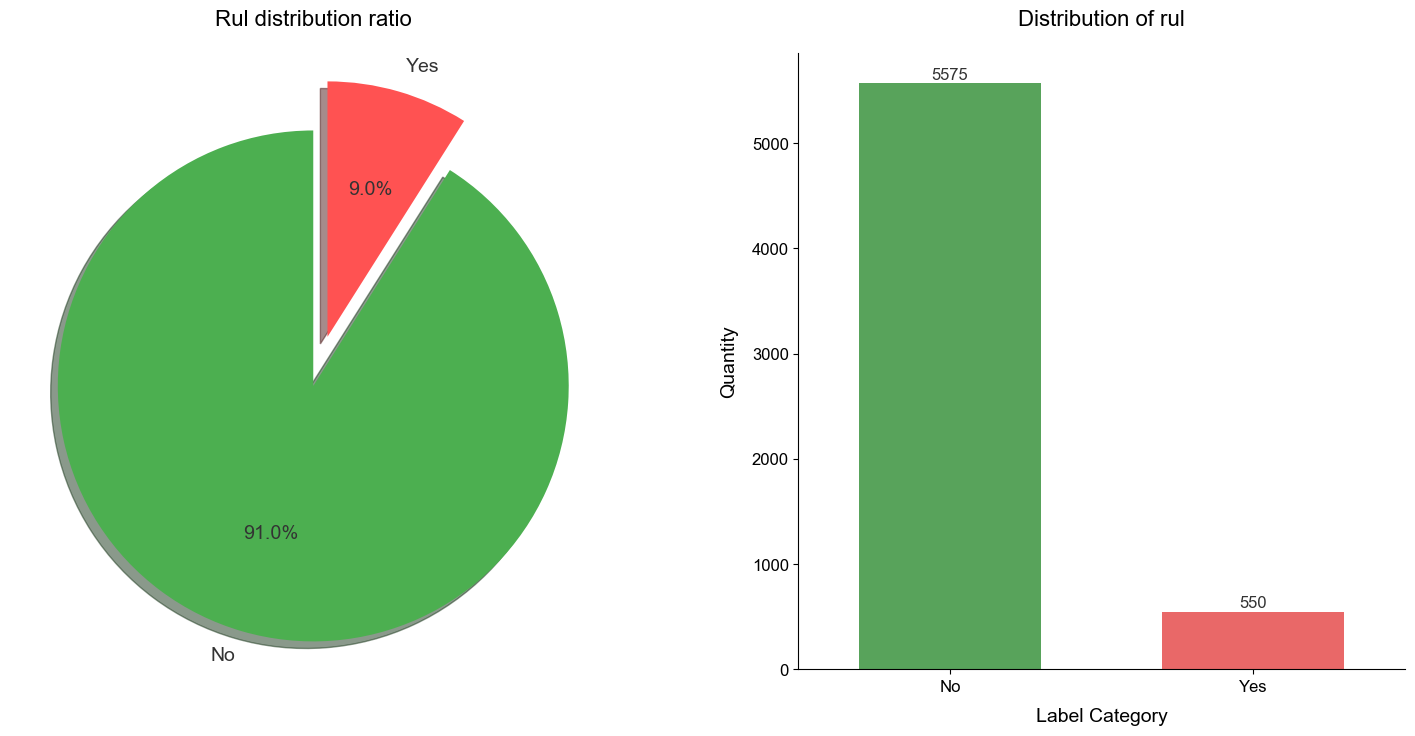

In [8]:
from utils import plot_label_distribution

plot_label_distribution(
    df=train, label_desc=LABEL_DESC,
    # pie_title=f'{LABEL_DESC} distribution ratio'.capitalize(),
    # bar_title=f'distribution of {LABEL_DESC}'.capitalize(),
)

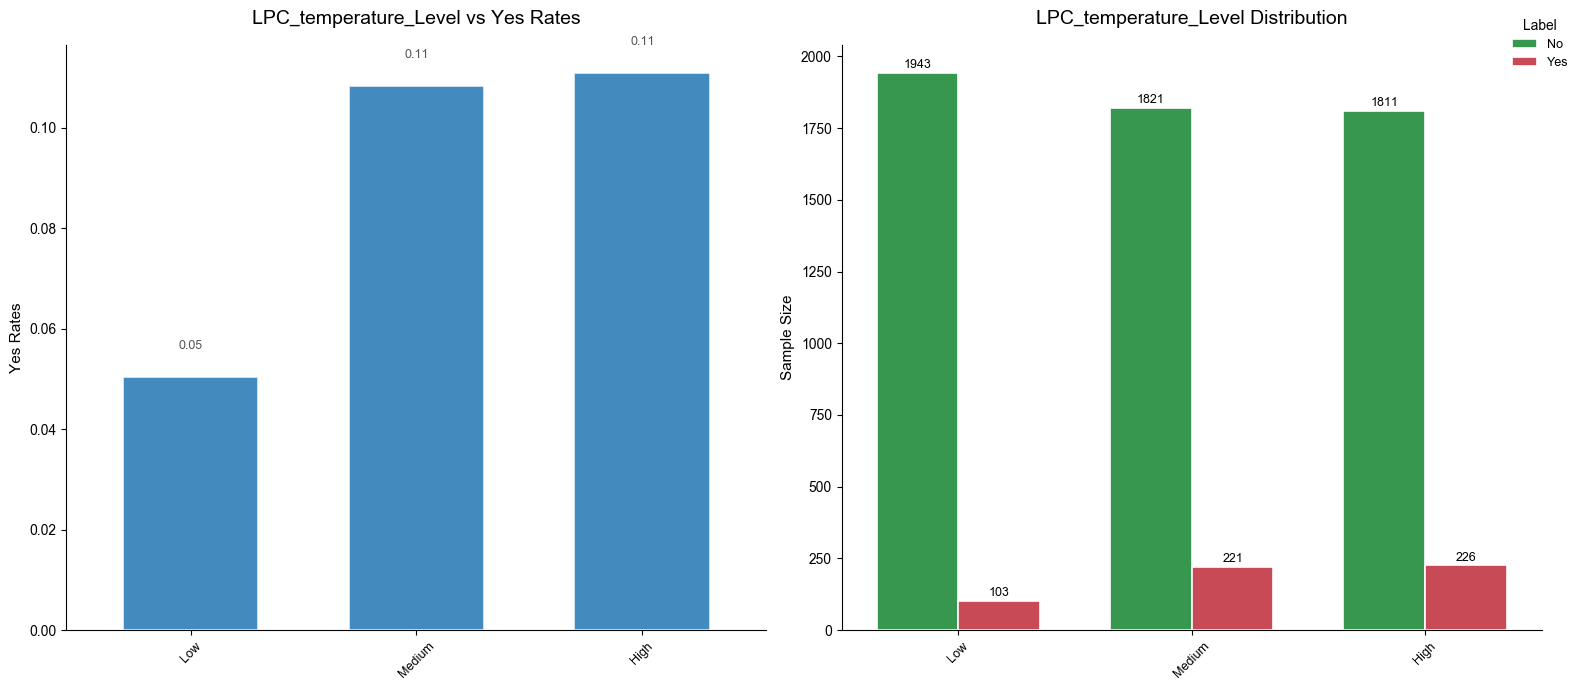

In [9]:
from utils import plot_discrete_variable_label_relationship
train['LPC_temperature_Level'] = pd.qcut(train['LPC outlet temperature (◦R)'], q=3, labels=['Low', 'Medium', 'High'])

discrete_variables = ['LPC_temperature_Level']
# variables = ['Substrate_Type', 'Deposition_Method', 'Material_Type']
for var in discrete_variables:
    plot_discrete_variable_label_relationship(
        df=train,
        var=var,
        label=LABEL,
        label_desc=LABEL_DESC,
    )

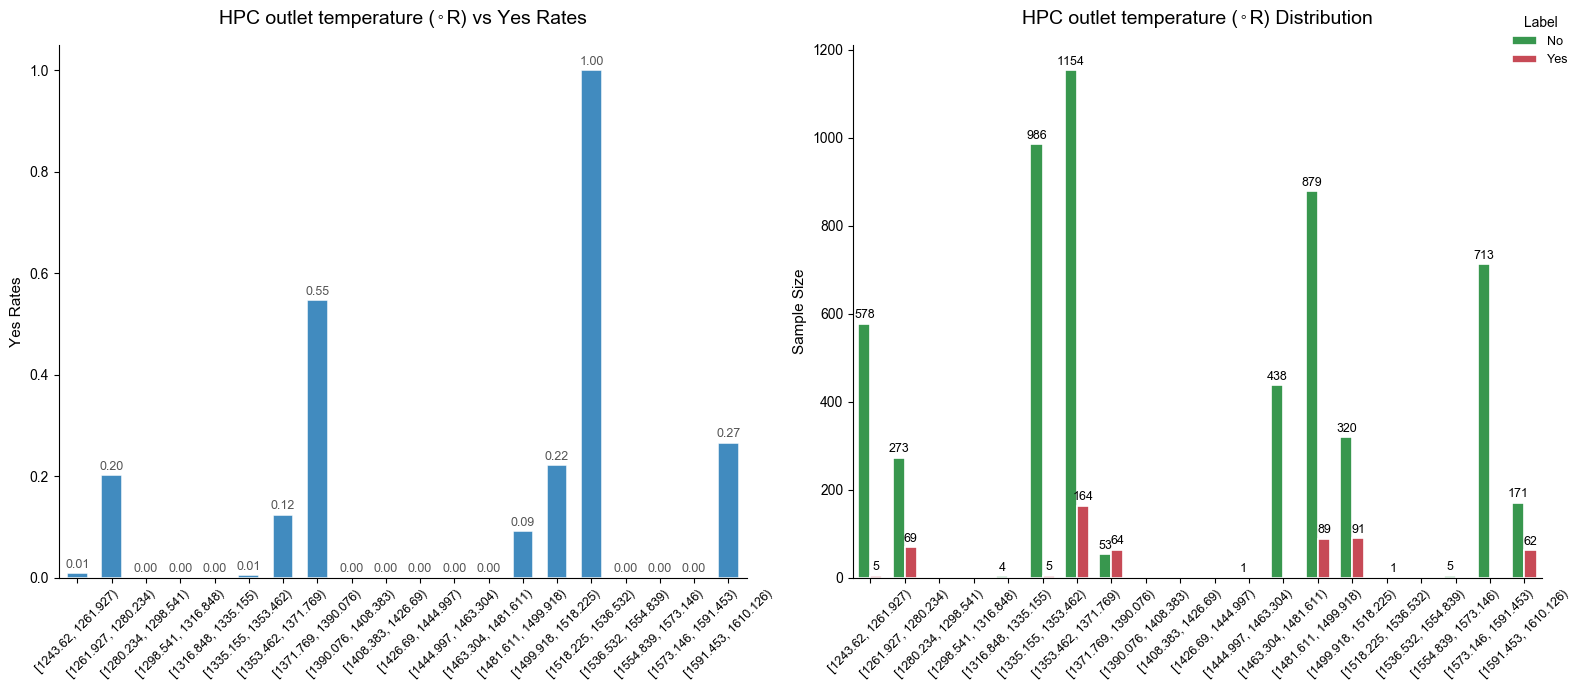

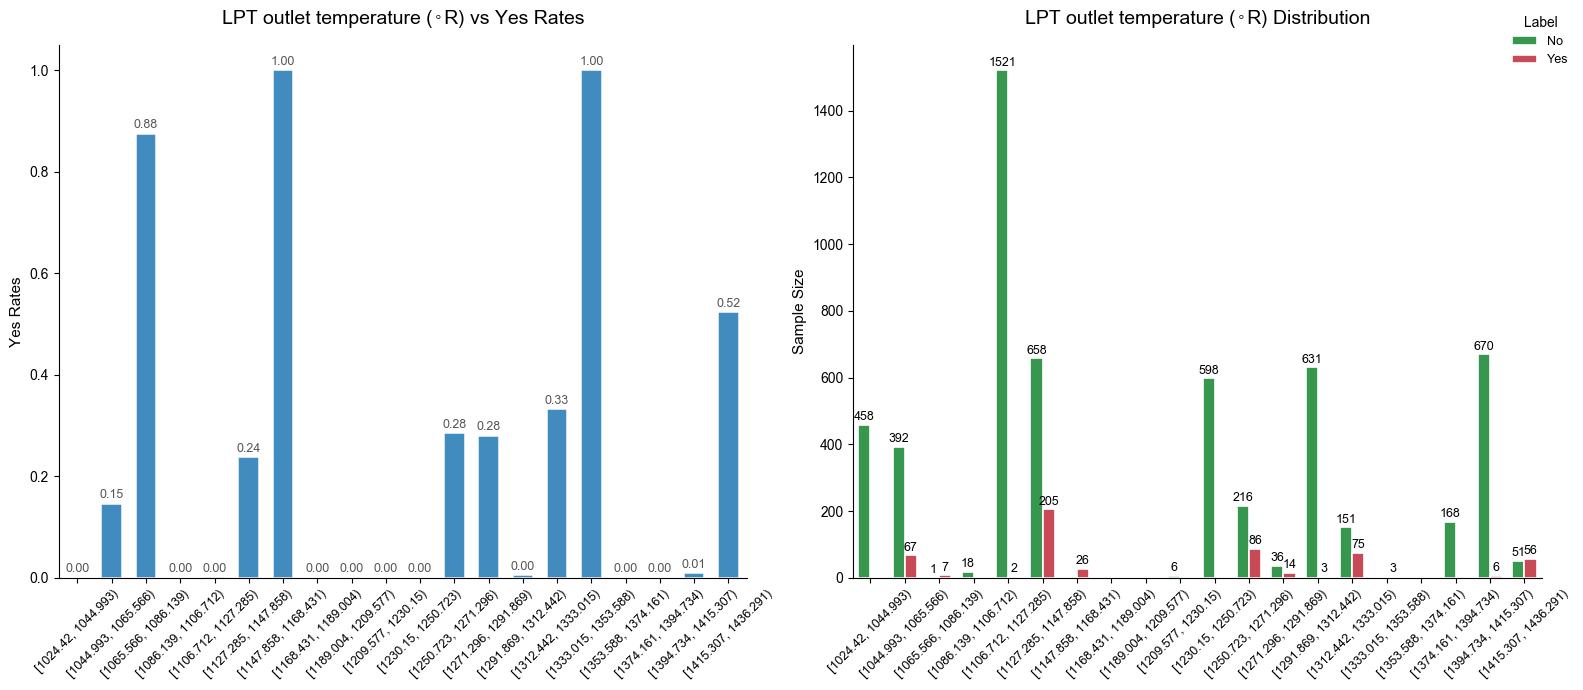

In [10]:
from utils import plot_continuous_variable_label_relationship

continuous_variables = [
    'HPC outlet temperature (◦R)', 'LPT outlet temperature (◦R)' 
]
for var in continuous_variables:
    plot_continuous_variable_label_relationship(
        df=train,
        var=var,
        label=LABEL,
        label_desc=LABEL_DESC,
        bins=20,
        names=None,
    )

In [11]:
train.columns

Index(['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3',
       'Fan inlet temperature (◦R)', 'LPC outlet temperature (◦R)',
       'HPC outlet temperature (◦R)', 'LPT outlet temperature (◦R)',
       'Fan inlet Pressure (psia)', 'bypass-duct pressure (psia)',
       'HPC outlet pressure (psia)', 'Physical fan speed (rpm)',
       'Physical core speed (rpm)', 'Engine pressure ratio (P50/P2)',
       'HPC outlet Static pressure (psia)',
       'Ratio of fuel flow to Ps30 (pps/psia)', 'Corrected fan speed (rpm)',
       'Corrected core speed (rpm)', 'Bypass Ratio', 'Burner fuel-air ratio',
       'Bleed Enthalpy', 'Required fan speed', 'Required fan conversion speed',
       'High-pressure turbines Cool air flow',
       'Low-pressure turbines Cool air flow', 'RUL', 'rul',
       'LPC_temperature_Level'],
      dtype='object')

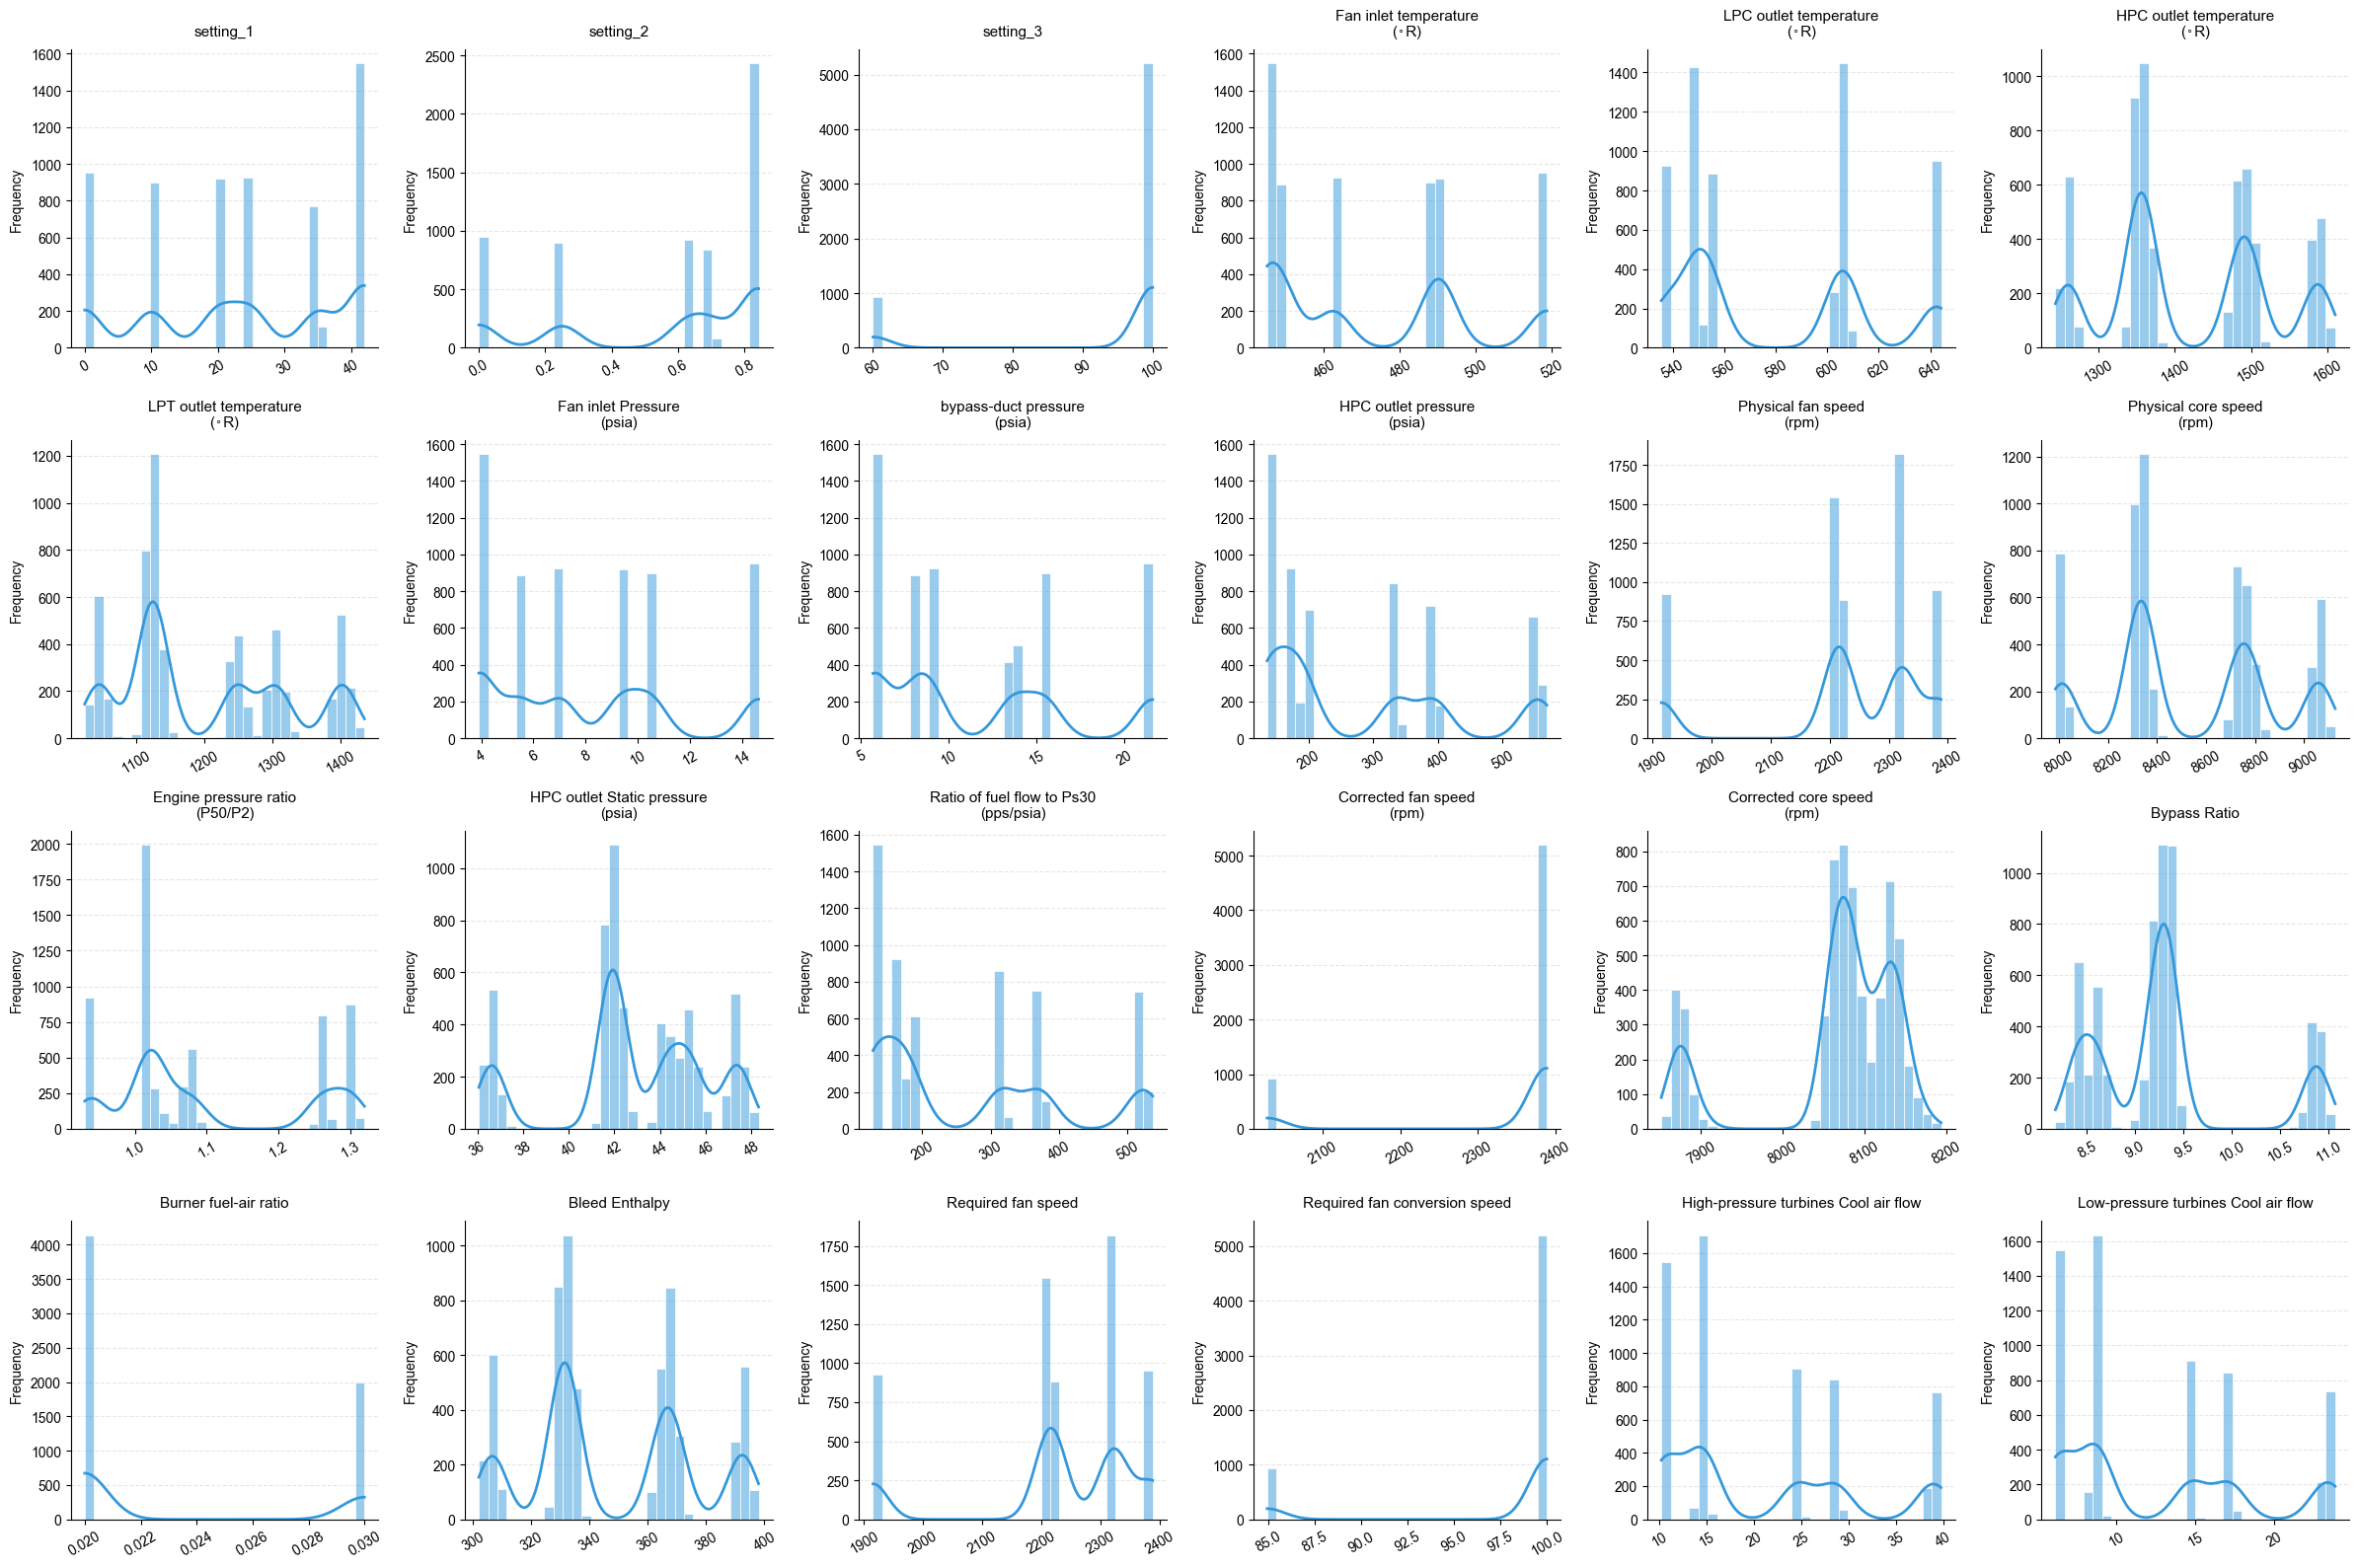

In [12]:
from utils import plot_variables_distribution

# 主要特征
NUM_FEATURE_NAMES = ['setting_1', 'setting_2', 'setting_3',
       'Fan inlet temperature (◦R)', 'LPC outlet temperature (◦R)',
       'HPC outlet temperature (◦R)', 'LPT outlet temperature (◦R)',
       'Fan inlet Pressure (psia)', 'bypass-duct pressure (psia)',
       'HPC outlet pressure (psia)', 'Physical fan speed (rpm)',
       'Physical core speed (rpm)', 'Engine pressure ratio (P50/P2)',
       'HPC outlet Static pressure (psia)',
       'Ratio of fuel flow to Ps30 (pps/psia)', 'Corrected fan speed (rpm)',
       'Corrected core speed (rpm)', 'Bypass Ratio', 'Burner fuel-air ratio',
       'Bleed Enthalpy', 'Required fan speed', 'Required fan conversion speed',
       'High-pressure turbines Cool air flow',
       'Low-pressure turbines Cool air flow', 'RUL']
plot_variables_distribution(
    df=train,
    variables=NUM_FEATURE_NAMES,
)

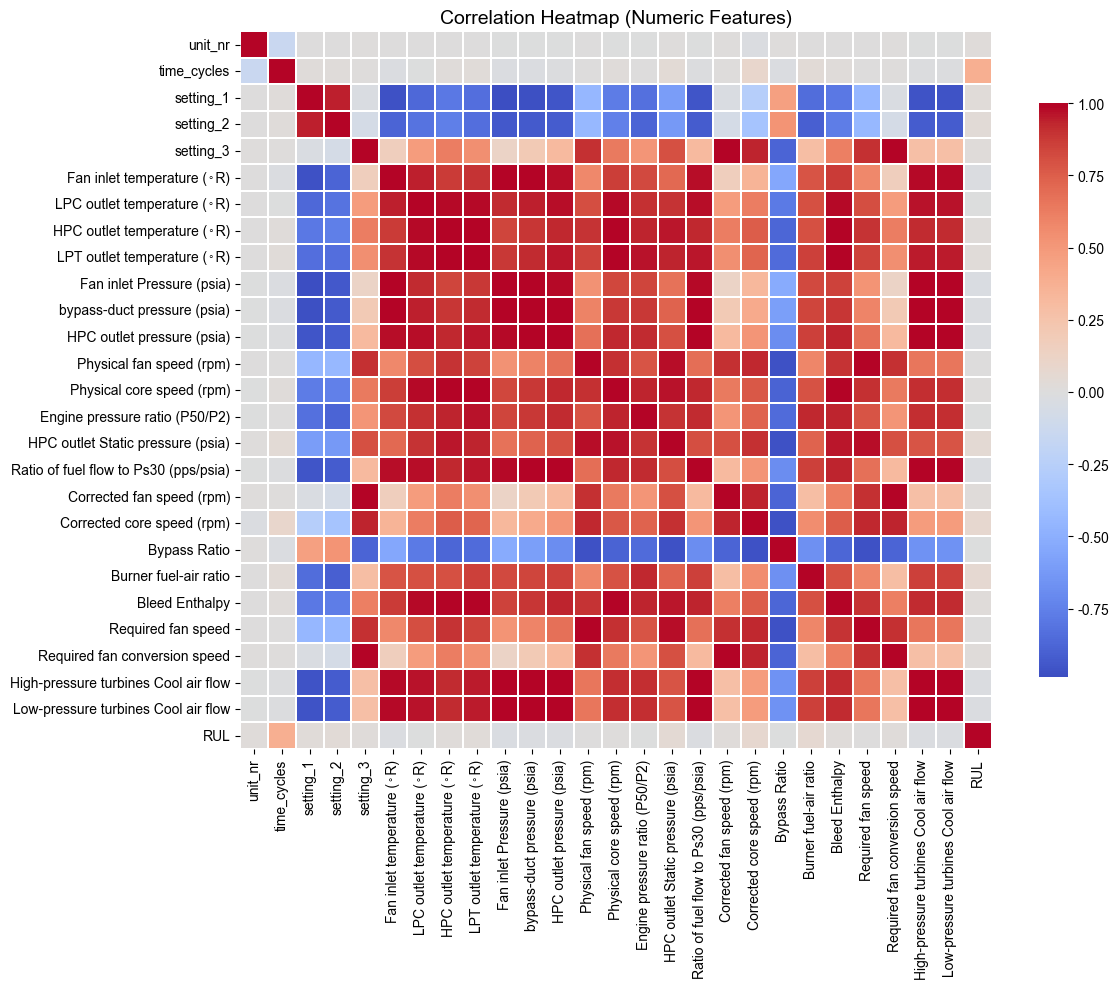

In [13]:
# ------------------------------------------------------------------
# Figure (Paper-like): Correlation Heatmap (Numeric Features)
# ------------------------------------------------------------------
from utils import plot_heatmap

plot_heatmap(train)
save_paper_figure('fig2_corr_heatmap.png', dpi=300, bbox_inches='tight')


# <a id='toc6_'></a>[数据预处理](#toc0_)


功能：处理数据中不规范列名与字符串，处理数据中的缺失值和异常值，同时记录异常/缺失标记，为建模做准备  
本数据干净且完整，故未做更多处理

In [14]:
class DataPreprocessing:
    def __init__(self):
        pass
    
    def fit(self, X):
        pass
    
    def transform(self, X):
        """对数据进行清洗转换：处理异常值、填充缺失值、添加标记列"""
        # 复制输入数据，避免修改原始数据
        X = X.copy()
        pass
        # 返回处理后的数据集
        return X

# <a id='toc7_'></a>[特征工程](#toc0_)

1. **工况与阶段特征编码**  
   对操作设置（Setting 2）进行二值化处理以区分高低负荷工况（High Load Mode），将连续的运行周期（Time Cycles）进行有序分箱编码（划分磨合期、稳定期、老化期），将非线性的时间维度转化为模型易于理解的生命周期阶段特征。

2. **传感器数值优化转换**  
   对物理核心转速、修正风扇转速等高量级、高偏度的传感器特征进行对数变换（Log Transform），平滑数据分布；同时清洗特征名称，去除特殊符号（如 °、/）与空格，确保特征格式符合模型训练的标准要求。

3. **物理机理新特征构建**  
   基于热力学原理构建压比（Pressure Ratio）、温比及燃油效率等关键物理指标，生成“压力-温度”交互特征以近似表达气体能量状态，并计算关键传感器的历史趋势（Delta变化率），深度挖掘设备性能的动态衰退规律。

4. **数据安全与完整性保障**  
   采用副本操作保护原始数据，建立健壮的异常处理机制，将比率计算中可能产生的无穷值（Inf）替换为缺失值并进行零填充，处理时间序列差分产生的头部缺失，保障特征工程全链路的数值稳定性

In [15]:
class FeatureGenerator:
    """特征生成器类，用于对发动机传感器数据进行特征工程处理，生成具有物理可解释性的特征"""
    
    def transform(self, X):
        """
        对输入数据进行特征转换处理
        
        参数:
            X: pandas.DataFrame，原始输入数据 (包含 unit_nr, time_cycles, settings, sensors)
            
        返回:
            pandas.DataFrame，处理后的特征数据
        """
        # 复制输入数据，避免修改原始数据
        X = X.copy()

        # -------------------------------------------------------
        # 1. 对 Setting 2 (操作设置) 进行二值化/分类处理
        # -------------------------------------------------------
        # 数据分析显示 setting_2 主要聚集在 <0.5 (低负荷) 和 >=0.5 (高负荷)
        X['High_Load_Mode'] = (X['setting_2'] >= 0.5).astype(int)

        # -------------------------------------------------------
        # 2. 对 time_cycles (运行周期) 进行分箱/有序编码
        # -------------------------------------------------------
        # 将连续的运行周期离散化为生命周期阶段：早期、中期、晚期、超期
        # 这有助于模型捕捉不同老化阶段的非线性特征
        X['Lifecycle_Stage'] = pd.cut(
            X['time_cycles'], 
            bins=[0, 50, 150, 250, 1000], 
            labels=[0, 1, 2, 3] # 0:磨合期, 1:稳定期, 2:老化期, 3:高危期
        ).astype(int)

        # -------------------------------------------------------
        # 3. 生成物理比率特征 (Thermodynamic Ratios)
        # -------------------------------------------------------
        # 在物理模型中，比率往往比单一传感器读数更能反映系统效率。
        
        # 压比 (Pressure Ratio): 高压出口压力 / 风扇入口压力 (P30 / P2)
        # 反映压气机的增压能力，是核心性能指标
        X['Pressure_Ratio_HPC'] = X['HPC outlet pressure (psia)'] / (X['Fan inlet Pressure (psia)'] + 1e-6)
        
        # 温比 (Temperature Ratio): 低压涡轮出口温度 / 高压出口温度 (T50 / T30)
        # 反映涡轮的做功效率和热转换率
        X['Temp_Ratio_LPT_HPC'] = X['LPT outlet temperature (◦R)'] / (X['HPC outlet temperature (◦R)'] + 1e-6)
        
        # 燃油效率代理变量: 燃油流量 / 物理核心转速
        # 单位转速消耗的燃油量，反映燃烧室效率
        X['Fuel_Efficiency_Proxy'] = X['Ratio of fuel flow to Ps30 (pps/psia)'] / (X['Physical core speed (rpm)'] + 1e-6)

        # -------------------------------------------------------
        # 4. 生成交互特征 (Sensor Interactions)
        # -------------------------------------------------------
        # 结合压力和温度，近似表达气体的能量状态 (Enthalpy proxy ~ P * T)
        
        # 高压压气机出口能量代理: P30 * T30
        X['HPC_Energy_Proxy'] = X['HPC outlet pressure (psia)'] * X['HPC outlet temperature (◦R)']

        # -------------------------------------------------------
        # 5. 对数值特征进行对数变换
        # -------------------------------------------------------
        # 对数值较大且波动剧烈的转速类特征进行平滑，使其更接近正态分布
        columns_to_log = [
            'Physical fan speed (rpm)', 
            'Physical core speed (rpm)', 
            'Corrected fan speed (rpm)', 
            'Corrected core speed (rpm)'
        ]
        for col in columns_to_log:
            if col in X.columns:
                # 添加 log_ 前缀，使用 log1p 避免 0 值错误
                X[f'log_{col.split(" ")[0]}'] = np.log1p(X[col].clip(lower=0))

        # -------------------------------------------------------
        # 6. 生成趋势特征 (Trend Features)
        # -------------------------------------------------------
        # 计算关键传感器相对于 10 个周期前的变化率 (Slope/Difference)
        # 注意：这需要数据按 unit_nr 和 time_cycles 排序
        
        # 关键传感器列表
        key_sensors = ['LPT outlet temperature (◦R)', 'HPC outlet pressure (psia)']
        
        # 确保按发动机和时间排序
        X_sorted = X.sort_values(by=['unit_nr', 'time_cycles'])
        
        for col in key_sensors:
            # 计算差分：当前值 - 5个周期前的值
            # Groupby 保证了不会计算到不同发动机之间的数据
            col_short_name = col.split(' ')[0] # 简化列名
            X[f'{col_short_name}_Delta_5'] = X_sorted.groupby('unit_nr')[col].diff(5).fillna(0)

        # -------------------------------------------------------
        # 7. 数据清洗与收尾
        # -------------------------------------------------------
        # 处理可能出现的无穷值 (除零导致)，替换为缺失值
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
        # 简单的缺失值填充 (0 或 前向填充)
        X.fillna(0, inplace=True)
        
        # 返回处理后的特征数据
        return X

1. 从训练数据中分离目标变量（转为整数）和特征数据，复制测试数据。
2. 用训练特征拟合预处理模型，再分别对训练和测试特征做预处理。
3. 通过特征生成器对预处理后的训练、测试特征进行特征工程，确保处理一致性，为建模做准备。

In [16]:
# 从训练数据中提取目标变量，并转换为整数类型（确保模型能正确处理标签）
train_y = train[LABEL].astype(int)

# 从训练数据中删除目标变量列，得到纯特征数据（用于模型训练的输入特征）
train_X = train.drop(columns=[LABEL, LABEL_DESC, 'LPC_temperature_Level'])

# 复制测试数据（避免后续操作修改原始测试数据）
test_X  = test.copy()

# 初始化数据预处理类实例（假设该类包含缺失值处理、异常值处理等基础预处理逻辑）
preprocessor = DataPreprocessing()

# 用训练数据拟合预处理模型（学习训练数据中的统计特性，如缺失值填充策略等）
preprocessor.fit(train_X)

# 对训练特征数据应用预处理（使用拟合好的参数对训练数据进行转换）
train_proc = preprocessor.transform(train_X)

# 对测试特征数据应用同样的预处理（保证训练集和测试集处理方式一致）
test_proc  = preprocessor.transform(test_X)

# 初始化特征生成器实例（即前面定义的FeatureGenerator类，用于生成高级特征）
feat_gen = FeatureGenerator()

# 对预处理后的训练数据进行特征工程（生成衍生特征，如比例特征、交互特征等）
train_fe = feat_gen.transform(train_proc)

# 对预处理后的测试数据进行同样的特征工程（保持特征一致性）
test_fe  = feat_gen.transform(test_proc)

1. 精准划分特征类型
2. 为不同特征类型构建专属处理管道
3. 整合列转换器与应用完整处理流程

In [17]:
def clean_feature_names(columns):
    new_columns = []
    for col in columns:
        # 1. 替换特殊字符 (括号, &, %, 逗号) 为下划线
        new_col = re.sub(r'[(),&%\s:-]+', '_', col)
        # 2. 去除首尾可能的下划线
        new_col = new_col.strip('_')
        new_columns.append(new_col)

    return new_columns

In [18]:
from utils import construct_process_pipeline

# 划分类别型特征列：筛选数据类型为object的列（通常为字符串类型的类别特征）
cat_cols = [c for c in train_fe.columns if train_fe[c].dtype == 'object']

# 划分数值型特征列：除类别特征外的其他列（通常为int/float类型的连续或离散数值特征）
num_cols = [c for c in train_fe.columns if c not in cat_cols]

# 构建预处理流程管道
preprocess = construct_process_pipeline(num_cols, cat_cols)

# 用训练集拟合完整的预处理流程（学习数值特征的中位数、类别特征的众数和编码规则等）
# 并对训练特征数据进行最终转换，得到可直接输入模型的特征矩阵
X_train = preprocess.fit_transform(train_fe)
columns = clean_feature_names(preprocess.get_feature_names_out())  # 处理特征名称中的违规符号
X_train = pd.DataFrame(X_train, columns=columns)

# 用拟合好的预处理流程转换测试特征数据（保证与训练集处理逻辑完全一致）
X_test = preprocess.transform(test_fe)
X_test = pd.DataFrame(X_test, columns=columns)

In [19]:
X_train.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,Fan_inlet_temperature_◦R,LPC_outlet_temperature_◦R,HPC_outlet_temperature_◦R,LPT_outlet_temperature_◦R,Fan_inlet_Pressure_psia,...,High_Load_Mode,Lifecycle_Stage,Pressure_Ratio_HPC,Temp_Ratio_LPT_HPC,Fuel_Efficiency_Proxy,HPC_Energy_Proxy,log_Physical,log_Corrected,LPT_Delta_5,HPC_Delta_5
0,225.0,48.0,25.0079,0.6210,60.0,462.54,535.65,1246.26,1027.39,7.05,...,1.0,0.0,24.629784,0.824379,0.020464,216400.5864,8.987023,8.970498,0.0,0.0
1,225.0,49.0,10.0004,0.2501,100.0,489.05,603.67,1490.09,1293.17,10.52,...,0.0,0.0,37.325092,0.867847,0.042221,585098.7394,9.078162,9.002518,0.0,0.0
2,225.0,50.0,20.0033,0.7000,100.0,491.19,606.91,1475.42,1230.66,9.35,...,1.0,0.0,35.404274,0.834108,0.035823,488408.2826,9.072027,8.992771,0.0,0.0
3,225.0,51.0,42.0004,0.8401,100.0,445.00,549.06,1335.91,1108.50,3.91,...,1.0,1.0,35.176462,0.829771,0.015661,183741.0614,9.023440,8.995732,0.0,0.0
4,225.0,52.0,42.0044,0.8416,100.0,445.00,549.25,1341.61,1115.23,3.91,...,1.0,1.0,35.214825,0.831262,0.015593,184726.2809,9.024689,8.995366,0.0,0.0


# <a id='toc8_'></a>[贝叶斯优化参数空间](#toc0_)

In [20]:
# ------------------------------------------------------------------
# 小样本快速优化（用 3 折 & 700 样本）
# ------------------------------------------------------------------
train_size = 800 if X_train.shape[0] > 800 else int(X_train.shape[0] * 0.8)
sample_idx, _ = train_test_split(
    np.arange(X_train.shape[0]), stratify=train_y, train_size=train_size, random_state=42
)
X_sample, y_sample = X_train.iloc[sample_idx], train_y.iloc[sample_idx]

class_weight = len(train_y) / (2 * np.bincount(train_y))  # 类别权重
xgb_scale_weight = class_weight[1] / class_weight[0] if 'class_weight' in locals() else 1.0

In [21]:
from utils import (
    bayes_opt_serial, bayes_opt, TunedMLP,
    lr_space, svc_space, dt_space, rf_space,
    gbdt_space, nb_space, mlp_space,
    lgb_space, xgb_space, cat_space,
)

# ================= 基础模型 (Sklearn) =================
print('【逻辑回归 (LR) 贝叶斯优化】')
model = LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
lr_model, lr_best = bayes_opt(model, lr_space, X_sample, y_sample, n_iter=12)

print('【支持向量机 (SVM) 贝叶斯优化】')
# SVM 训练较慢，probability=True 会更慢，但在小样本(800)下可接受
model = SVC(probability=False, class_weight='balanced', random_state=42)
svm_model, svm_best = bayes_opt(model, svc_space, X_sample, y_sample, n_iter=1)

print('【决策树 (DT) 贝叶斯优化】')
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model, dt_best = bayes_opt(model, dt_space, X_sample, y_sample, n_iter=12)

print('【随机森林 (RF) 贝叶斯优化】')
model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_model, rf_best = bayes_opt(model, rf_space, X_sample, y_sample, n_iter=12)

print('【GBDT (Sklearn) 贝叶斯优化】')
# Sklearn GBDT 原生不支持 class_weight 参数，通常需手动处理样本权重或忽略
model = GradientBoostingClassifier(random_state=42)
gbdt_model, gbdt_best = bayes_opt(model, gbdt_space, X_sample, y_sample, n_iter=12)

print('【朴素贝叶斯 (NB) 贝叶斯优化】')
model =  GaussianNB()
nb_model, nb_best = bayes_opt(model, nb_space, X_sample, y_sample, n_iter=12)

print('【MLP (神经网络) 贝叶斯优化】')
model = TunedMLP(max_iter=1000, early_stopping=True, random_state=42)
mlp_model, mlp_best = bayes_opt_serial(model, mlp_space, X_sample, y_sample, n_iter=12)
mlp_best = dict(mlp_best)
best_idx = int(mlp_best.pop('layer_idx')) # 移除 layer_idx
mlp_best['hidden_layer_sizes'] = [(50,), (100,), (50, 50)][best_idx] # 加回 hidden_layer_sizes

# ================= 提升树模型 (Boosting) =================
print('【LightGBM 贝叶斯优化】')
model = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgb_model, lgb_best = bayes_opt(model, lgb_space, X_sample, y_sample, cv=3, n_iter=12)

print('【XGBoost 贝叶斯优化】')
model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss', tree_method='hist',
    n_jobs=-1, scale_pos_weight=xgb_scale_weight, random_state=42,
)
xgb_model, xgb_best = bayes_opt(model, xgb_space, X_sample, y_sample, cv=3, n_iter=12)

print('【CatBoost 贝叶斯优化】')
model = cb.CatBoostClassifier(
    loss_function='Logloss', eval_metric='F1', thread_count=-1,
    auto_class_weights='Balanced', random_state=42, verbose=False,
)
cat_model, cat_best = bayes_opt(model, cat_space, X_sample, y_sample, cv=3, n_iter=1)

【逻辑回归 (LR) 贝叶斯优化】
【支持向量机 (SVM) 贝叶斯优化】
【决策树 (DT) 贝叶斯优化】
【随机森林 (RF) 贝叶斯优化】
【GBDT (Sklearn) 贝叶斯优化】
【朴素贝叶斯 (NB) 贝叶斯优化】
【MLP (神经网络) 贝叶斯优化】
【LightGBM 贝叶斯优化】
【XGBoost 贝叶斯优化】
【CatBoost 贝叶斯优化】


# <a id='toc9_'></a>[合成数据生成（KNN插值版）](#toc0_)
功能：通过KNN插值法为少数类生成合成样本，缓解数据不平衡问题

In [22]:
from utils import apply_sampling

# 设置采样策略，可选值：none / smote / undersample / combined / knn
SAMPLING_STRATEGY = 'smote'
# 打印当前使用的采样策略
print(f'>>> 数据采样策略：{SAMPLING_STRATEGY}')

>>> 数据采样策略：smote


# <a id='toc10_'></a>[5 折交叉验证训练](#toc0_)

In [23]:
from utils import f1_best_threshold, get_best_f1

# 1.1 基础模型 (Sklearn)
oof_lr, pred_lr = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_svm, pred_svm = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_dt, pred_dt = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_rf, pred_rf = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_gbdt, pred_gbdt = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_nb, pred_nb = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_mlp, pred_mlp = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])

# 1.2 提升树模型 (Boosting)
oof_lgb, pred_lgb = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_xgb, pred_xgb = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_cat, pred_cat = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (trn, val) in enumerate(skf.split(X_train, train_y), 1):
    print(f'=== Fold {fold} ===')
    X_resample, X_val = X_train.iloc[trn], X_train.iloc[val]
    y_resample, y_val = train_y.iloc[trn], train_y.iloc[val]

    # 采样仅对训练集
    X_trn, y_trn = apply_sampling(X_resample, y_resample, strategy=SAMPLING_STRATEGY)

    # ------------------------------------------------------
    # A组：Sklearn 类模型 (标准 .fit 接口)
    # ------------------------------------------------------
    # 1. Logistic Regression
    m_lr = LogisticRegression(**lr_best, class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1)
    m_lr.fit(X_trn, y_trn)
    oof_lr[val] = m_lr.predict_proba(X_val)[:, 1]
    pred_lr += m_lr.predict_proba(X_test)[:, 1] / skf.n_splits

    # 2. SVM (注意: probability=True 必须开启，速度较慢)
    m_svm = SVC(**svm_best, probability=True, class_weight='balanced', random_state=42)
    m_svm.fit(X_trn, y_trn)
    oof_svm[val] = m_svm.predict_proba(X_val)[:, 1]
    pred_svm += m_svm.predict_proba(X_test)[:, 1] / skf.n_splits

    # 3. Decision Tree
    m_dt = DecisionTreeClassifier(**dt_best, class_weight='balanced', random_state=42)
    m_dt.fit(X_trn, y_trn)
    oof_dt[val] = m_dt.predict_proba(X_val)[:, 1]
    pred_dt += m_dt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 4. Random Forest
    m_rf = RandomForestClassifier(**rf_best, class_weight='balanced', n_jobs=-1, random_state=42)
    m_rf.fit(X_trn, y_trn)
    oof_rf[val] = m_rf.predict_proba(X_val)[:, 1]
    pred_rf += m_rf.predict_proba(X_test)[:, 1] / skf.n_splits

    # 5. GBDT (Sklearn原生) - 不支持 class_weight
    m_gbdt = GradientBoostingClassifier(**gbdt_best, random_state=42)
    m_gbdt.fit(X_trn, y_trn)
    oof_gbdt[val] = m_gbdt.predict_proba(X_val)[:, 1]
    pred_gbdt += m_gbdt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 6. Naive Bayes - 不支持 class_weight
    m_nb = GaussianNB(**nb_best)    
    m_nb.fit(X_trn, y_trn)
    oof_nb[val] = m_nb.predict_proba(X_val)[:, 1]
    pred_nb += m_nb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 7. MLP - 不直接支持 class_weight
    m_mlp = MLPClassifier(**mlp_best, max_iter=1000, random_state=42)
    m_mlp.fit(X_trn, y_trn)
    oof_mlp[val] = m_mlp.predict_proba(X_val)[:, 1]
    pred_mlp += m_mlp.predict_proba(X_test)[:, 1] / skf.n_splits

    # ------------------------------------------------------
    # B组：Boosting 类模型 (支持 eval_set 早停)
    # ------------------------------------------------------
    # 8. LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best, class_weight='balanced', n_jobs=-1, verbose=-1)
    m_lgb.fit(X_trn, y_trn, eval_set=[(X_val, y_val)]) # callbacks=[lgb.early_stopping(50)] 可选
    oof_lgb[val] = m_lgb.predict_proba(X_val)[:, 1]
    pred_lgb += m_lgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 9. XGBoost
    neg, pos = np.bincount(y_trn)
    spw = neg / pos
    m_xgb = xgb.XGBClassifier(
        **xgb_best, tree_method='hist', n_jobs=-1,
        scale_pos_weight=spw, early_stopping_rounds=50
    )
    m_xgb.fit(X_trn, y_trn, eval_set=[(X_val, y_val)], verbose=0)
    oof_xgb[val] = m_xgb.predict_proba(X_val)[:, 1]
    pred_xgb += m_xgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 10. CatBoost
    m_cat = cb.CatBoostClassifier(
        **cat_best, thread_count=-1, verbose=False,
        auto_class_weights='Balanced', early_stopping_rounds=50
    )
    m_cat.fit(X_trn, y_trn, eval_set=(X_val, y_val))
    oof_cat[val] = m_cat.predict_proba(X_val)[:, 1]
    pred_cat += m_cat.predict_proba(X_test)[:, 1] / skf.n_splits

    print(f"   [Sklearn] LR:{get_best_f1(y_val, oof_lr[val]):.3f} | SVM:{get_best_f1(y_val, oof_svm[val]):.3f} | DT:{get_best_f1(y_val, oof_dt[val]):.3f} | RF:{get_best_f1(y_val, oof_rf[val]):.3f}")
    print(f"   [Others]  GBDT:{get_best_f1(y_val, oof_gbdt[val]):.3f} | NB:{get_best_f1(y_val, oof_nb[val]):.3f} | MLP:{get_best_f1(y_val, oof_mlp[val]):.3f}")
    print(f"   [Boosting] LGB:{get_best_f1(y_val, oof_lgb[val]):.3f} | XGB:{get_best_f1(y_val, oof_xgb[val]):.3f} | CAT:{get_best_f1(y_val, oof_cat[val]):.3f}")
    print("-" * 50)

=== Fold 1 ===
   [Sklearn] LR:0.586 | SVM:0.165 | DT:0.752 | RF:0.883
   [Others]  GBDT:0.912 | NB:0.391 | MLP:0.381
   [Boosting] LGB:0.916 | XGB:0.913 | CAT:0.924
--------------------------------------------------
=== Fold 2 ===
   [Sklearn] LR:0.588 | SVM:0.165 | DT:0.791 | RF:0.867
   [Others]  GBDT:0.892 | NB:0.385 | MLP:0.423
   [Boosting] LGB:0.916 | XGB:0.921 | CAT:0.893
--------------------------------------------------
=== Fold 3 ===
   [Sklearn] LR:0.569 | SVM:0.165 | DT:0.769 | RF:0.819
   [Others]  GBDT:0.859 | NB:0.382 | MLP:0.204
   [Boosting] LGB:0.900 | XGB:0.903 | CAT:0.893
--------------------------------------------------
=== Fold 4 ===
   [Sklearn] LR:0.602 | SVM:0.165 | DT:0.745 | RF:0.850
   [Others]  GBDT:0.922 | NB:0.381 | MLP:0.413
   [Boosting] LGB:0.907 | XGB:0.917 | CAT:0.904
--------------------------------------------------
=== Fold 5 ===
   [Sklearn] LR:0.580 | SVM:0.165 | DT:0.746 | RF:0.833
   [Others]  GBDT:0.900 | NB:0.440 | MLP:0.253
   [Boosting] 

# <a id='toc11_'></a>[最优模型选择（无模型融合）](#toc0_)


## <a id='toc11_1_'></a>[基于 OOF F1 的最优单模型选择](#toc0_)


In [24]:
# ======================================================
# 无模型融合版本：直接选择最优单模型（按 OOF 最佳 F1）
# ======================================================

# 1. 整理所有模型的 OOF 和 Test 预测值
# 格式: (短名, OOF数组, Test概率数组)
model_list = [
    ('LR',   oof_lr,   pred_lr),
    ('SVM',  oof_svm,  pred_svm),
    ('DT',   oof_dt,   pred_dt),
    ('RF',   oof_rf,   pred_rf),
    ('GBDT', oof_gbdt, pred_gbdt),
    ('NB',   oof_nb,   pred_nb),
    ('MLP',  oof_mlp,  pred_mlp),
    ('LGB',  oof_lgb,  pred_lgb),
    ('XGB',  oof_xgb,  pred_xgb),
    ('CAT',  oof_cat,  pred_cat)
]

# 2. 选择最佳单模型（基于 OOF 的最佳 F1）
name_map = {
    'LR': 'Logistic Regression',
    'SVM': 'SVM',
    'DT': 'Decision Tree',
    'RF': 'Random Forest',
    'GBDT': 'GBDT',
    'NB': 'Naive Bayes',
    'MLP': 'MLP',
    'LGB': 'LightGBM',
    'XGB': 'XGBoost',
    'CAT': 'CatBoost'
}

best_short = None
best_model_name = None
best_model_oof = None
best_model_test = None
best_thr = None
best_f1 = -1

print("=== 单模型 OOF 最佳 F1 表现 ===")
for short, oof, pred in model_list:
    # f1_best_threshold 返回 (threshold, f1_score)
    thr, f1 = f1_best_threshold(train_y, oof)
    print(f"{short:4s} | F1={f1:.4f} @ thr={thr:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr
        best_short = short
        best_model_name = name_map.get(short, short)
        best_model_oof = oof
        best_model_test = pred

print(f"\n>>> 最佳单模型（无融合）: 【{best_model_name}】({best_short})")
print(f">>> OOF 最佳 F1 : {best_f1:.4f}")
print(f">>> OOF 最佳阈值: {best_thr:.4f}")

# 3. 最终用于提交的 Test 概率（直接使用最佳单模型）
final_prob_test = best_model_test

=== 单模型 OOF 最佳 F1 表现 ===
LR   | F1=0.5706 @ thr=0.7331
SVM  | F1=0.1648 @ thr=0.5000
DT   | F1=0.7575 @ thr=0.9167
RF   | F1=0.8338 @ thr=0.6545
GBDT | F1=0.8907 @ thr=0.7060
NB   | F1=0.3771 @ thr=0.7537
MLP  | F1=0.2446 @ thr=0.0015
LGB  | F1=0.9033 @ thr=0.5933
XGB  | F1=0.9131 @ thr=0.7234
CAT  | F1=0.8944 @ thr=0.5999

>>> 最佳单模型（无融合）: 【XGBoost】(XGB)
>>> OOF 最佳 F1 : 0.9131
>>> OOF 最佳阈值: 0.7234


In [25]:
# ------------------------------------------------------------------
# Table (Paper-like): Model Performance Summary (OOF)
# ------------------------------------------------------------------
import os
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# 说明：这里使用 OOF 概率 + best_thr（最佳单模型阈值）做二值化，计算 Accuracy/F1；AUC 直接用概率
rows = []
for name, oof, _ in model_list:
    # 默认用全局 best_thr；如果你更想每个模型都用各自最优阈值，可改为 f1_best_threshold(y, oof)
    y_pred = (oof >= best_thr).astype(int)
    rows.append({
        'Model': name,
        'Accuracy(thr=best_thr)': accuracy_score(train_y, y_pred),
        'F1(thr=best_thr)': f1_score(train_y, y_pred),
        'ROC_AUC': roc_auc_score(train_y, oof),
    })

metrics_df = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False)
display(metrics_df)
save_exp_csv(metrics_df, 'model_performance_oof.csv', index=False)

,Model,Accuracy(thr=best_thr),F1(thr=best_thr),ROC_AUC
8,XGB,0.984490,0.913083,0.996323
7,LGB,0.982367,0.900552,0.995959
9,CAT,0.980735,0.890943,0.995574
4,GBDT,0.980082,0.888483,0.995196
3,RF,0.969796,0.827907,0.989738
0,LR,0.899429,0.566807,0.935024
2,DT,0.950041,0.749591,0.931597
5,NB,0.812898,0.375817,0.822895
6,MLP,0.593959,0.240611,0.676021
1,SVM,0.910204,0.000000,0.500000


>>> 已保存: exp_figs/model_performance_oof.csv


In [26]:
# ------------------------------------------------------------------
# Export: Model Metrics Table (Paper-like Table II) + Simple Bars
# ------------------------------------------------------------------
import os
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

rows = []
# 复用前面 model_list: (name, oof, pred)
for name, oof, _ in model_list:
    # 默认阈值 0.5 的 accuracy/f1（也可以用 best_thr，但为可比性这里统一 0.5）
    y_pred = (oof >= 0.5).astype(int)
    rows.append({
        'Model': name,
        'ROC_AUC': roc_auc_score(train_y, oof),
        'Accuracy@0.5': accuracy_score(train_y, y_pred),
        'F1@0.5': f1_score(train_y, y_pred)
    })

# 加入最佳单模型（无融合）
# rows.append({
#     'Model': f'Best({best_short})',
#     'ROC_AUC': roc_auc_score(train_y, best_model_oof),
#     'Accuracy@0.5': accuracy_score(train_y, (best_model_oof >= 0.5).astype(int)),
#     'F1@0.5': f1_score(train_y, (best_model_oof >= 0.5).astype(int))
# })
df_metrics = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False)
save_exp_csv(df_metrics, 'table2_model_metrics.csv', index=False)
save_paper_csv(df_metrics, 'table2_model_metrics.csv', index=False)

>>> 已保存: exp_figs/table2_model_metrics.csv


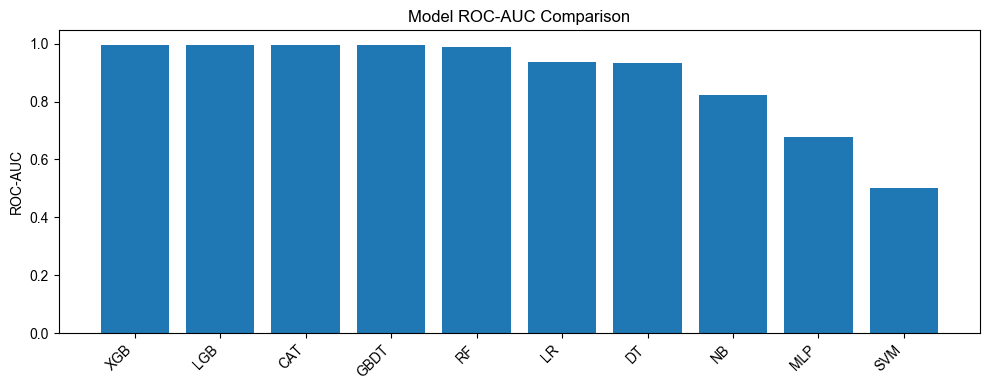

In [27]:
# 简单柱状图：ROC-AUC
plt.figure(figsize=(10, 4))
plt.bar(df_metrics['Model'], df_metrics['ROC_AUC'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('ROC-AUC')
plt.title('Model ROC-AUC Comparison')
plt.tight_layout()
save_exp_figure('model_auc_bar.png')
plt.show()
plt.close()

## <a id='toc11_2_'></a>[（已移除）Stacking/融合](#toc0_)

本版本已去除加权融合与 Stacking，仅保留“最优单模型选择”。


In [28]:
# Stacking / 融合已移除：本版本不再训练元模型。

# <a id='toc12_'></a>[提交文件](#toc0_)



In [29]:
predictions = (final_prob_test >= best_thr).astype(int) # 可换成 best_stack_pred
predictions = pd.concat([test_fe['unit_nr'], pd.Series(predictions)], axis=1, join='inner', names=['unit_nr', 'failure'])
failures_predictions = predictions.groupby('unit_nr').max().values.flatten()
results = pd.DataFrame({'unit_nr' : test_fe['unit_nr'].unique(), 'failure': failures_predictions})
results.to_csv('submission.csv', index=False)

# <a id='toc13_'></a>[结果可视化](#toc0_)

正在绘制 ROC/PR 曲线...


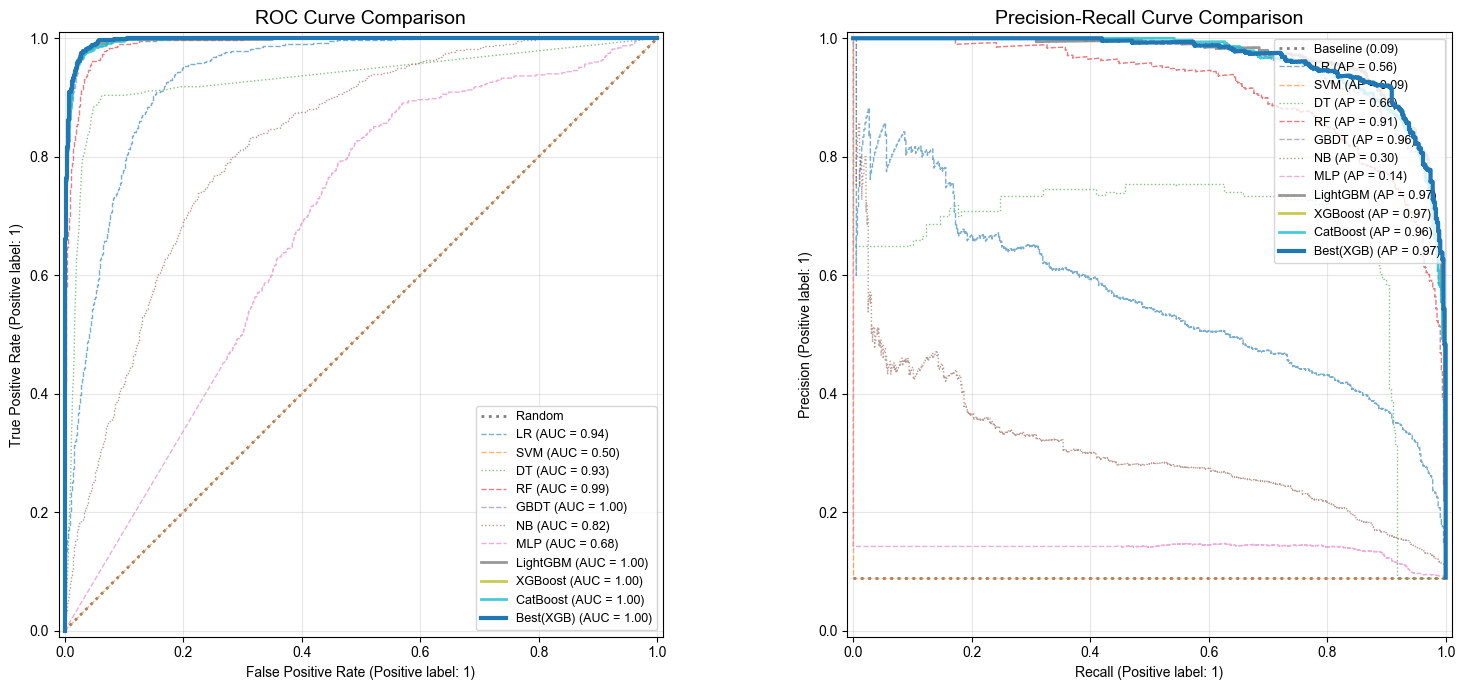

In [30]:
from utils import plot_roc_pr_curve

plot_data = [
    # --- 基础模型 (Sklearn) ---
    (oof_lr,   'LR',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_svm,  'SVM',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_dt,   'DT',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_rf,   'RF',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_gbdt, 'GBDT', {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_nb,   'NB',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_mlp,  'MLP',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    
    # --- 提升树模型 (Boosting) ---
    (oof_lgb,  'LightGBM', {'lw': 2, 'alpha': 0.8}),
    (oof_xgb,  'XGBoost',  {'lw': 2, 'alpha': 0.8}),
    (oof_cat,  'CatBoost', {'lw': 2, 'alpha': 0.8}),

    # --- 最佳单模型（无融合） ---
    (best_model_oof, f'Best({best_short})', {'lw': 3, 'alpha': 1.0, 'zorder': 10}),
    
    # --- 融合模型 (Ensemble) ---
]
plot_roc_pr_curve(train_y, plot_data)
save_paper_figure('roc_pr_all_models.png')

正在筛选最佳单模型...

>>> 最佳模型: 【XGBoost】
>>> 最佳 F1 : 0.9131
>>> 最佳阈值: 0.7234


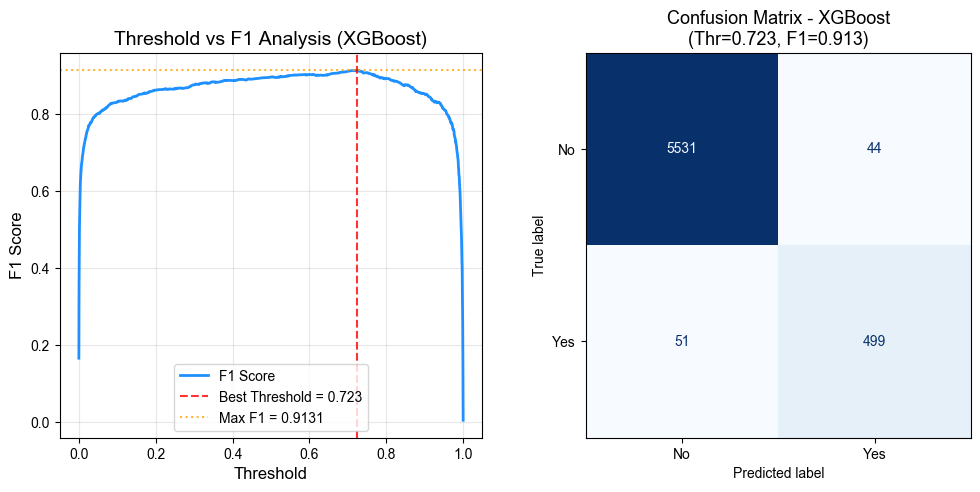

In [31]:
from utils import plot_best_model_analysis

# ======================================================
# 1. 筛选最好单模
# ======================================================
candidates = {
    'Logistic Regression': oof_lr,
    'SVM': oof_svm,
    'Decision Tree': oof_dt,
    'Random Forest': oof_rf,
    'GBDT': oof_gbdt,
    'Naive Bayes': oof_nb,
    'MLP': oof_mlp,
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat
}

best_model_name = None
best_model_oof = None
global_best_f1 = -1
global_best_thr = -1

print("正在筛选最佳单模型...")
for name, oof_pred in candidates.items():
    # 计算该模型下的最佳阈值和F1
    p, r, t = precision_recall_curve(train_y, oof_pred)
    f1_scores = 2 * (p * r) / (p + r + 1e-8)

    idx = np.argmax(f1_scores)
    current_max_f1 = f1_scores[idx]
    
    current_best_thr = t[idx] if idx < len(t) else t[-1]
    
    if current_max_f1 > global_best_f1:
        global_best_f1 = current_max_f1
        global_best_thr = current_best_thr
        best_model_name = name
        best_model_oof = oof_pred

print(f"\n>>> 最佳模型: 【{best_model_name}】")
print(f">>> 最佳 F1 : {global_best_f1:.4f}")
print(f">>> 最佳阈值: {global_best_thr:.4f}")

# ======================================================
# 绘制最佳单模型的 阈值-F1 曲线 和 混淆矩阵
# ======================================================
plot_best_model_analysis(
    train_y, best_model_name, best_model_oof, global_best_f1, global_best_thr,
    display_labels=label_map_int2str.values(),
)
save_exp_figure(f'threshold_f1_confusion_matrix_{best_model_name.replace(" ", "_")}')
plt.show()
plt.close()

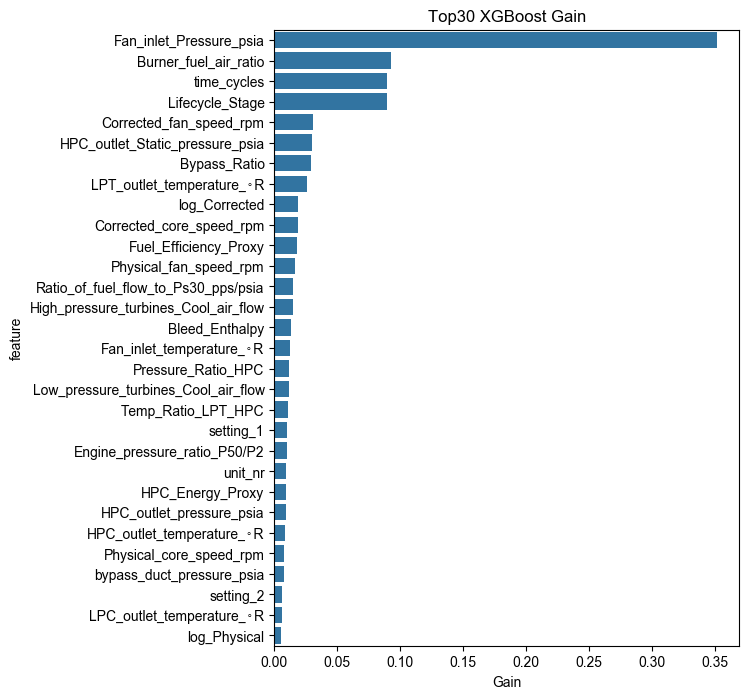

In [32]:
from utils import plot_feature_importance

feature_names = list(X_train.columns)
# ========== 特征重要性（XGBoost示例） ==========
plot_feature_importance(model=m_xgb, feature_names=feature_names)
save_exp_figure('xgb_importance.png')

In [33]:
# ------------------------------------------------------------------
# SHAP 汇总（用融合模型代表）
# ------------------------------------------------------------------
print('>>> SHAP 解释性（融合模型代表）')
explainer = shap.TreeExplainer(m_xgb)          # 可用 m_xgb / m_lgb / m_cat
sample_num = 2000  # 建议保留 sample_num 以防止全量数据导致内存溢出
X_subset = X_train.iloc[:sample_num]
shap_values_raw = explainer.shap_values(X_subset)  # 计算 SHAP 值

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        expected_value = explainer.expected_value[1]
    else:
        expected_value = explainer.expected_value
else:
    shap_values = shap_values_raw
    expected_value = explainer.expected_value

>>> SHAP 解释性（融合模型代表）


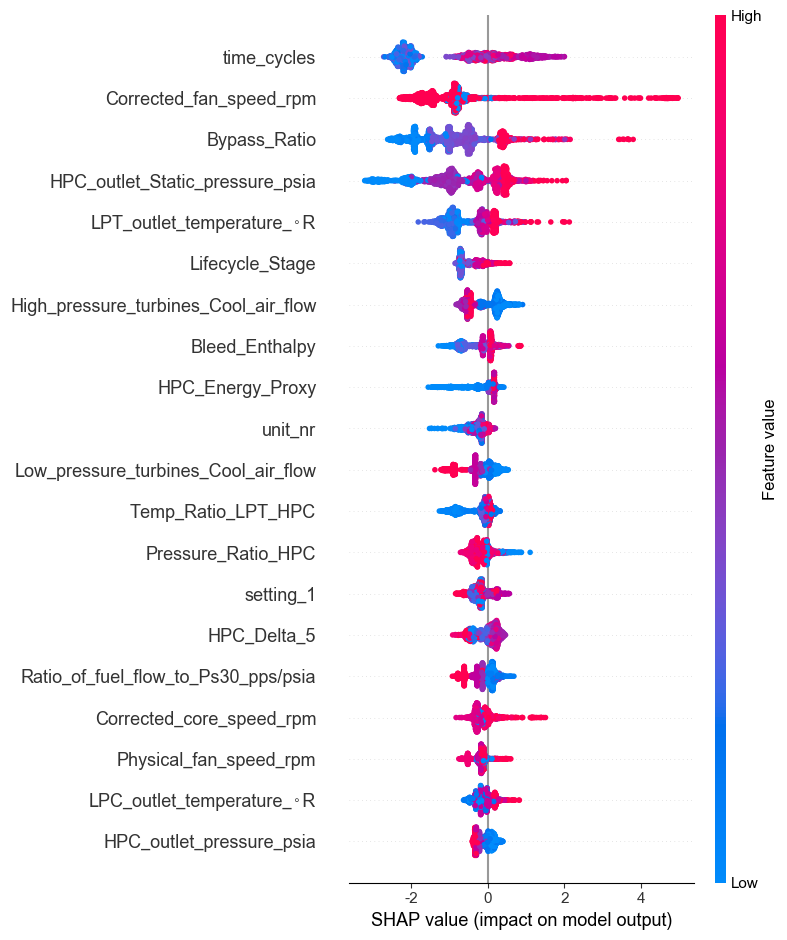

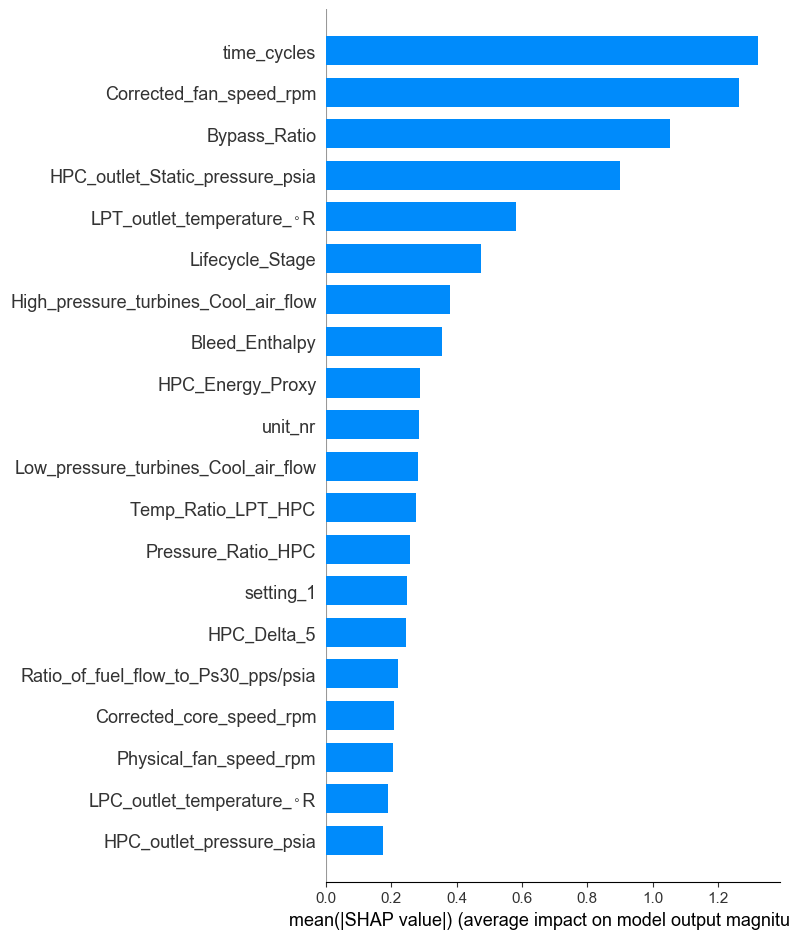

In [34]:
# === 1. 摘要图 (Summary Plot) ===
plt.figure()
shap.summary_plot(shap_values, X_subset, feature_names=feature_names, show=False)
plt.tight_layout()
# save_exp_figure("shap_summary.png", dpi=300)
save_paper_figure("fig4_shap_summary.png", dpi=300)
plt.show()
plt.close()

# === 摘要条形图 (Bar Plot) ===
plt.figure()
shap.summary_plot(shap_values, X_subset, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
# save_exp_figure("shap_bar.png", dpi=300)
save_paper_figure("fig3_shap_bar.png", dpi=300)
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

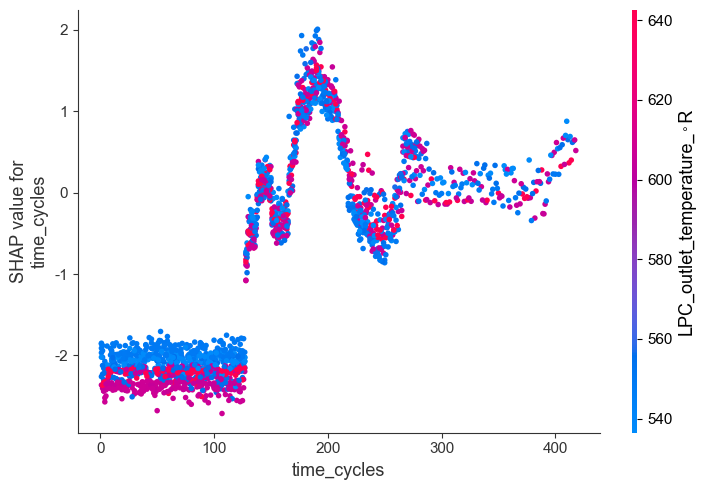

In [35]:
# === 2. SHAP 依赖图（最重要特征） ===
top_feat_idx = np.abs(shap_values).mean(0).argmax() 
plt.figure()
shap.dependence_plot(top_feat_idx, shap_values, X_subset, feature_names=feature_names, show=False)
plt.tight_layout()
# save_exp_figure("shap_dependence.png", dpi=300)
save_paper_figure("fig5_shap_dependence.png", dpi=300)
plt.show()
plt.close()

In [36]:
X_train.columns

Index(['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3',
       'Fan_inlet_temperature_◦R', 'LPC_outlet_temperature_◦R',
       'HPC_outlet_temperature_◦R', 'LPT_outlet_temperature_◦R',
       'Fan_inlet_Pressure_psia', 'bypass_duct_pressure_psia',
       'HPC_outlet_pressure_psia', 'Physical_fan_speed_rpm',
       'Physical_core_speed_rpm', 'Engine_pressure_ratio_P50/P2',
       'HPC_outlet_Static_pressure_psia',
       'Ratio_of_fuel_flow_to_Ps30_pps/psia', 'Corrected_fan_speed_rpm',
       'Corrected_core_speed_rpm', 'Bypass_Ratio', 'Burner_fuel_air_ratio',
       'Bleed_Enthalpy', 'Required_fan_speed', 'Required_fan_conversion_speed',
       'High_pressure_turbines_Cool_air_flow',
       'Low_pressure_turbines_Cool_air_flow', 'High_Load_Mode',
       'Lifecycle_Stage', 'Pressure_Ratio_HPC', 'Temp_Ratio_LPT_HPC',
       'Fuel_Efficiency_Proxy', 'HPC_Energy_Proxy', 'log_Physical',
       'log_Corrected', 'LPT_Delta_5', 'HPC_Delta_5'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

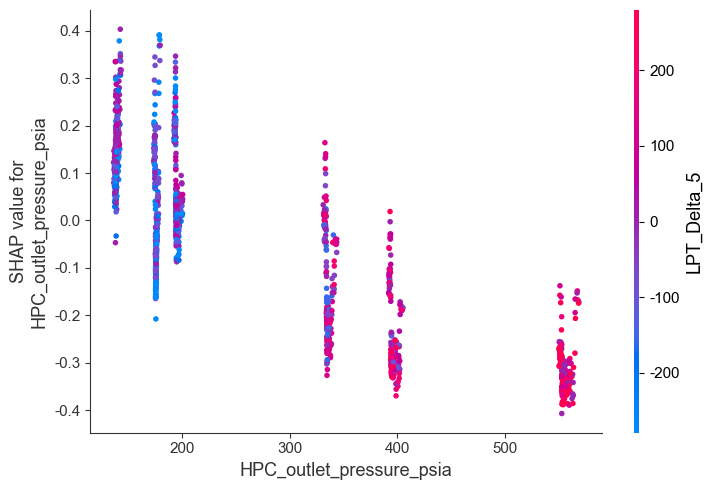

<Figure size 640x480 with 0 Axes>

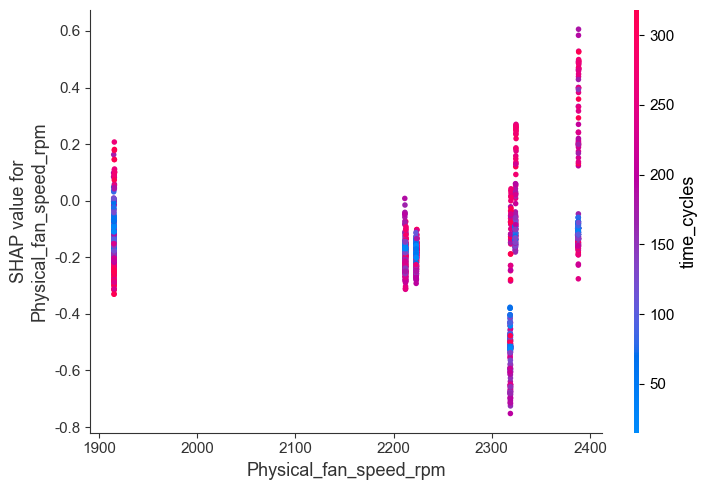

<Figure size 640x480 with 0 Axes>

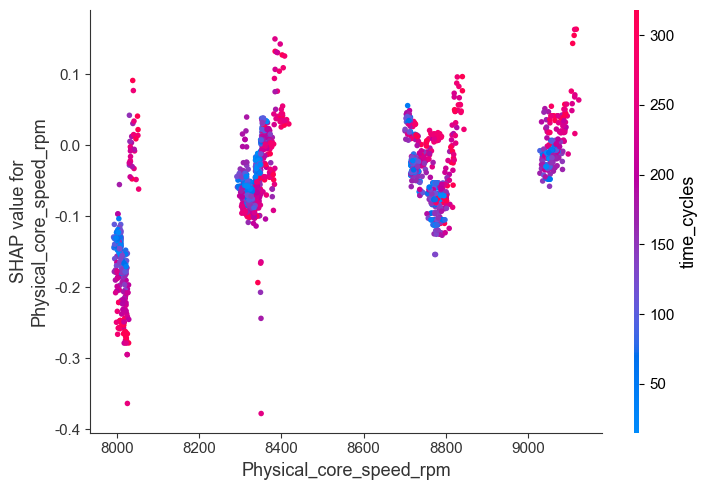

In [37]:
# === 2b. SHAP 依赖图（指定特征：Interest Rate / Annual Income） ===
specified_features = ['Physical_fan_speed_rpm',
       'Physical_core_speed_rpm',
       'HPC_outlet_pressure_psia']
specifieidxd_idx = [i for i, _ in enumerate(feature_names) if _ in specified_features]
for fidx, fname in zip(specifieidxd_idx, specified_features):
    plt.figure()
    shap.dependence_plot(
        fidx, shap_values, X_subset,
        feature_names=feature_names, show=False
    )
    plt.tight_layout()
    save_exp_figure(f"shap_dependence_{fname}.png", dpi=300, bbox_inches='tight')
    save_paper_figure(f"shap_dependence_{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

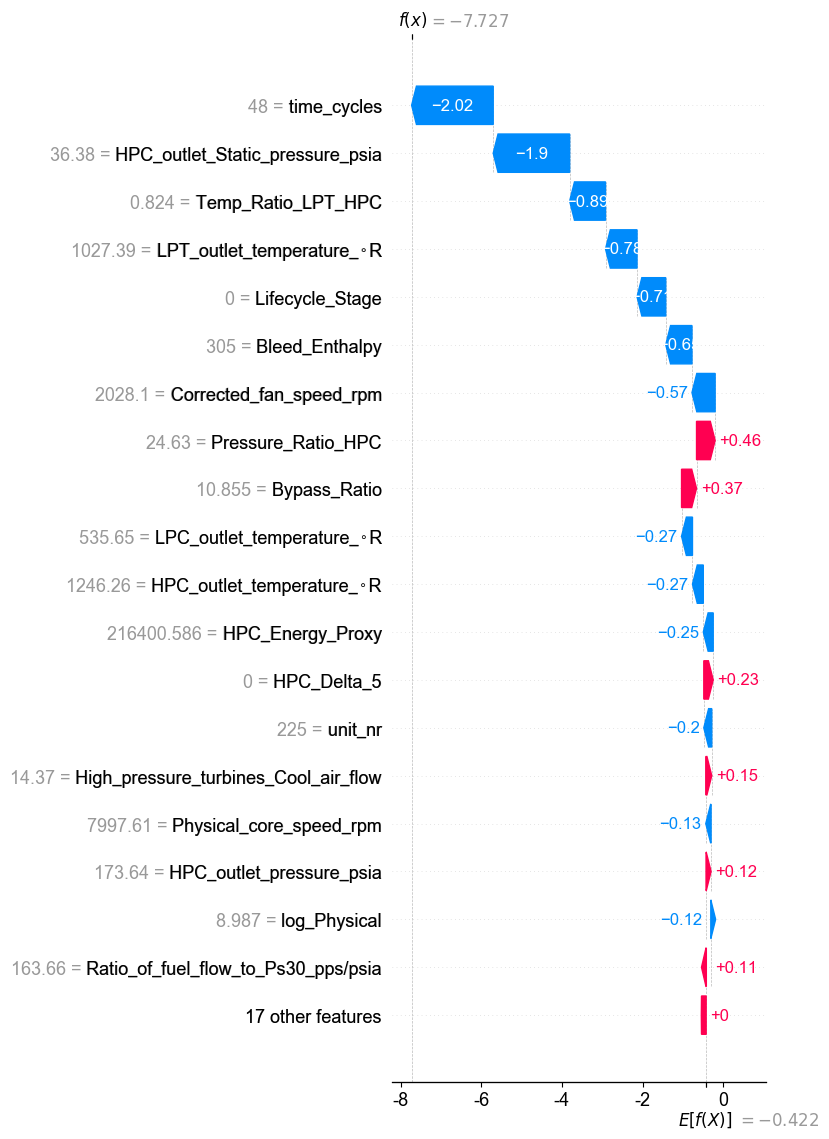

In [38]:
# === 3. SHAP 瀑布图（单样本示例） ===
sample_idx = 0 
plt.figure()
# 使用 Explanation 对象适配新版绘图接口
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=expected_value,
        data=X_subset.iloc[sample_idx],
        feature_names=feature_names
    ),
    max_display=20, show=False
)
plt.tight_layout()
save_exp_figure("shap_waterfall.png", dpi=300)
plt.show()
plt.close()